### Optimal control of the Wilson-Cowan model
This notebook shows how to compute the optimal control (OC) signal for the Wilson-Cowan model for a simple example task.

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import os

while os.getcwd().split(os.sep)[-1] != "neurolib":
    os.chdir('..')

# We import the model, stimuli, and the optimal control package
from neurolib.models.wc import WCModel
from neurolib.utils.stimulus import ZeroInput
from neurolib.control.optimal_control import oc_wc
from neurolib.utils.plot_oc import plot_oc_singlenode, plot_oc_network

import torch
import gym
from gym import spaces
from stable_baselines3 import PPO

# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


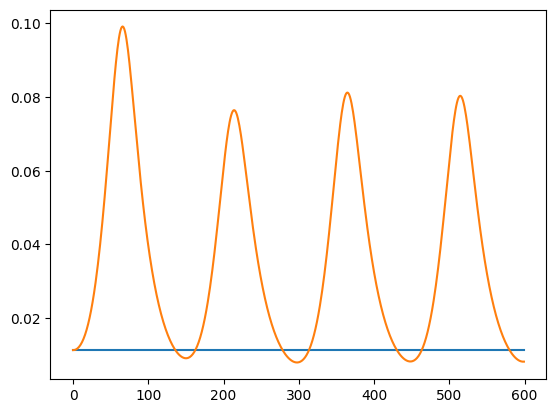

In [8]:
# We import the model
wc = WCModel()

# Some parameters to define stimulation signals
dt = wc.params["dt"]
duration = 60.
amplitude = 1.
period = duration/4.

time = np.arange(0, duration+dt, dt)

# We define a "zero-input", and a sine-input
zero_input = ZeroInput().generate_input(duration=duration+dt, dt=dt)
input = np.copy(zero_input)
input[0,1:-1] = amplitude * np.sin(2.*np.pi*np.arange(0,duration-0.1, dt)/period) # other functions or random values can be used as well
test_input = np.copy(input)

# We set the duration of the simulation and the initial values
wc.params["duration"] = duration
x_init = 0.011344980024880755
y_init = 0.013324978712489702
wc.params["exc_init"] = np.array([[x_init]])
wc.params["inh_init"] = np.array([[y_init]])

wc.params["exc_ext"] = zero_input
wc.params["inh_ext"] = zero_input
wc.run()

state_timeseries = wc.exc[0,:]

wc.params["exc_ext"] = input
wc.params["inh_ext"] = zero_input
wc.run()

target_timeseries = wc.exc[0,:]

plt.plot(state_timeseries)
plt.plot(target_timeseries)
plt.show()

In [9]:
def polynomial(x, coeffs):
    factor = 0.01
    shift = 50
    return coeffs[0] + coeffs[1] * (factor * (x-shift)) + coeffs[2] * (factor * (x-shift))**2 #+ coeffs[3] * (factor * (x-shift)) **3 + coeffs[4] * (factor * (x-shift)) **4 + coeffs[5] * (factor * (x-shift)) **5

In [574]:
# We set the stimulus in x and y variables, and run the simulation
wc.params["exc_ext"] = zero_input
wc.params["inh_ext"] = zero_input
wc.run()

n_data = int(1e4)
n_coeffs = 3

train_data_coeffs = np.zeros(( n_data,  n_coeffs))
train_data_timeseries = np.zeros(( n_data,  wc.exc.shape[1]))

#fig, ax = plt.subplots(2, 1, figsize=(16,8))

amp = 3.
for k in range(n_data):
    coeffs = [amp* (np.random.rand()-0.5), amp* (np.random.rand()-0.5), amp* (np.random.rand()-0.5)]#, amp* (np.random.rand()-0.5), amp* (np.random.rand()-0.5), amp* (np.random.rand()-0.5) ]
    inp = polynomial(time, coeffs)
    wc.params["exc_ext"] = inp
    wc.run()

    #ax[0].plot(wc.exc[0,:])
    #ax[1].plot(inp)

    train_data_timeseries[k, :] = wc.exc[0,:]
    train_data_coeffs[k, :] = coeffs

#plt.show()

n_test = int(1e1)
test_data_coeffs = np.zeros(( n_test,  n_coeffs))
test_data_timeseries = np.zeros(( n_test,  wc.exc.shape[1]))

for k in range(n_test):
    coeffs = [amp* (np.random.rand()-0.5), amp* (np.random.rand()-0.5), amp* (np.random.rand()-0.5)]#, amp* (np.random.rand()-0.5), amp* (np.random.rand()-0.5), amp* (np.random.rand()-0.5) ]
    print(coeffs)
    inp = polynomial(time, coeffs)
    wc.params["exc_ext"] = inp
    wc.run()



    test_data_timeseries[k, :] = wc.exc[0,:]
    test_data_coeffs[k, :] = coeffs

[0.4415486871944607, 1.489677917825227, -0.20687114059138734]
[0.3540220769956326, 0.2077507983440936, -0.8618202873952954]
[-0.2573220150223461, 0.49270458282630647, 0.1125925761029235]
[0.7961360605313645, 0.7842256585732607, -0.42939063043287085]
[-0.31023412979594855, 0.10154798794438702, -1.284777872673163]
[0.15918854495537127, 1.1967296027378638, 0.4755122187319295]
[-1.17243781164742, 0.5444946371024493, 0.21348013974621793]
[-0.018860455306428547, 0.6035509491353694, 0.6461084431937729]
[1.4818931606623051, 0.6860318308205401, -1.38352866853]
[-1.119304590313045, -0.29166213384012885, 0.12137561746611403]


In [527]:
class Data(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
        self.len = self.X.shape[0]
       
    def __getitem__(self, index):
        return self.X[index], self.y[index]
   
    def __len__(self):
        return self.len
   
batch_size = 32
train_data = Data(train_data_timeseries, train_data_coeffs)
train_dataloader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=False)

# Check it's working
for batch, (X, y) in enumerate(train_dataloader):
    print(f"Batch: {batch+1}")
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    break
    
batch_size = 1
test_data = Data(test_data_timeseries, test_data_coeffs)
test_dataloader = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=False)

for batch, (X, y) in enumerate(test_dataloader):
    print(f"Batch: {batch+1}")
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    break

Batch: 1
X shape: torch.Size([32, 200])
y shape: torch.Size([32, 3])
Batch: 1
X shape: torch.Size([1, 200])
y shape: torch.Size([1, 3])


In [528]:
input_dim = len(time)-1
hidden_dim = int(0.2*len(time))
output_dim = n_coeffs

class NeuralNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(NeuralNetwork, self).__init__()
        self.layer_1 = nn.Linear(input_dim, hidden_dim)
        nn.init.kaiming_uniform_(self.layer_1.weight, nonlinearity="relu")
        self.layer_2 = nn.Linear(hidden_dim, output_dim)
        self.double()
       
    def forward(self, x):
        x = torch.nn.functional.relu(self.layer_1(x))
        x = torch.nn.functional.sigmoid(self.layer_2(x))
        return x
       
model = NeuralNetwork(input_dim, hidden_dim, output_dim)
print(model)

NeuralNetwork(
  (layer_1): Linear(in_features=200, out_features=40, bias=True)
  (layer_2): Linear(in_features=40, out_features=3, bias=True)
)


In [ ]:
input_dim = len(time)-1
output_dim = n_coeffs

class NeuralNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear_stack = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.Linear(input_dim, 500),
            nn.Linear(500, 50),
            nn.Linear(50, output_dim),
        )
        self.double()
 
    def forward(self, x):
        return self.linear_stack(x)
       
model = NeuralNetwork(input_dim, output_dim)
print(model)

NeuralNetwork(
  (linear_stack): Sequential(
    (0): Linear(in_features=200, out_features=200, bias=True)
    (1): Linear(in_features=200, out_features=500, bias=True)
    (2): Linear(in_features=500, out_features=50, bias=True)
    (3): Linear(in_features=50, out_features=3, bias=True)
  )
)


0
100
200
300
400
500
600
700
800
900
Training Complete


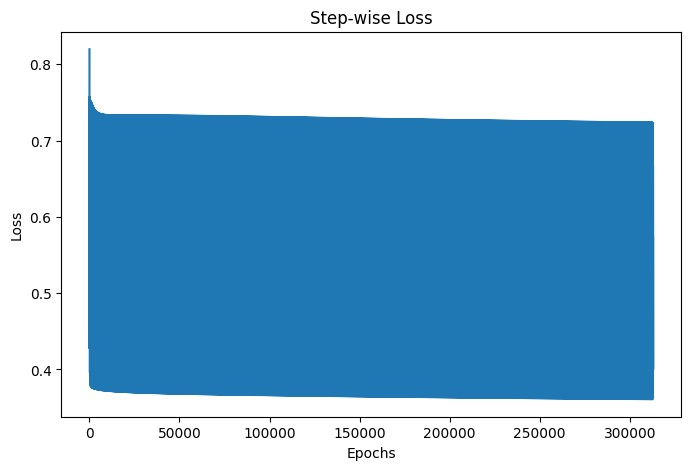

In [530]:
learning_rate = 0.1
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
num_epochs = int(1e3)
loss_values = []

for epoch in range(num_epochs):
    if epoch%100 == 0: print(epoch)
    for X, y in train_dataloader:
        
        # zero the parameter gradients
        optimizer.zero_grad()
       
        # X = output, y = control
        pred = model(X)
        if False:
            plt.plot(X[0,:].detach().numpy())
            plt.plot(pred[0,:].detach().numpy())
            plt.plot(y[0,:].detach().numpy() )
            plt.show()
        loss = loss_fn(pred, y)
        loss_values.append(loss.item())
        loss.backward()
        optimizer.step()

print("Training Complete")
step = range(len(loss_values))

fig, ax = plt.subplots(figsize=(8,5))
plt.plot(step, np.array(loss_values))
plt.title("Step-wise Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

torch.Size([1, 3])
loss =  0.7964278398630212


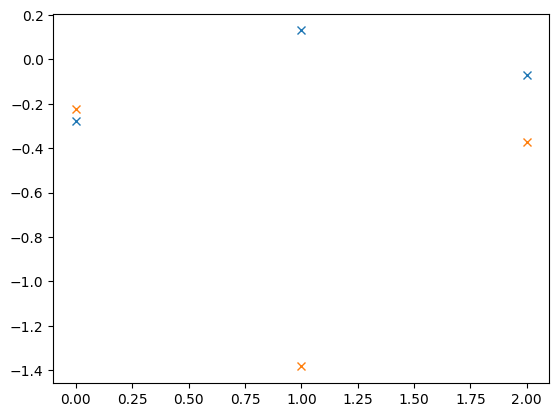

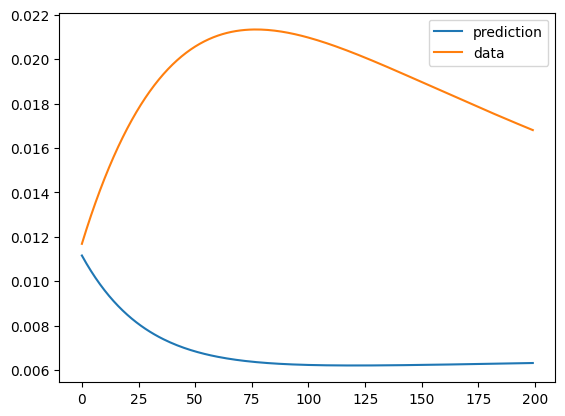

torch.Size([1, 3])
loss =  0.7295508333220301


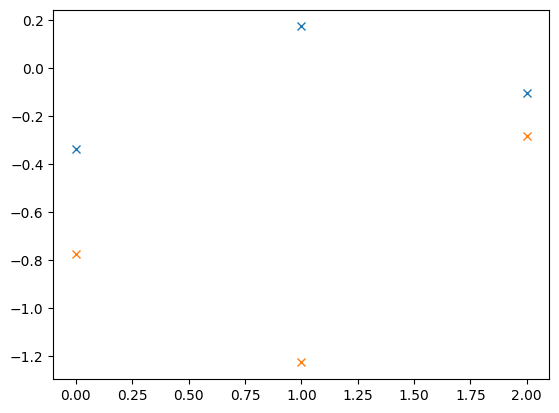

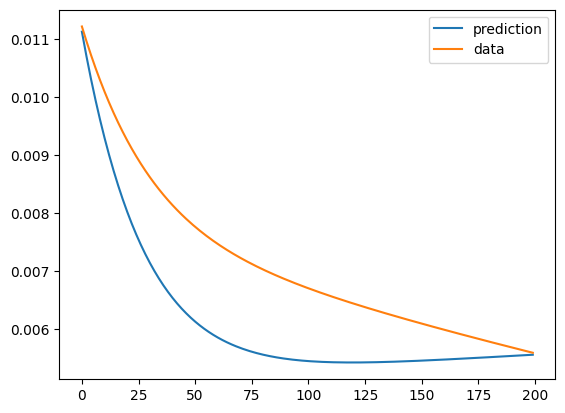

torch.Size([1, 3])
loss =  0.592718655342298


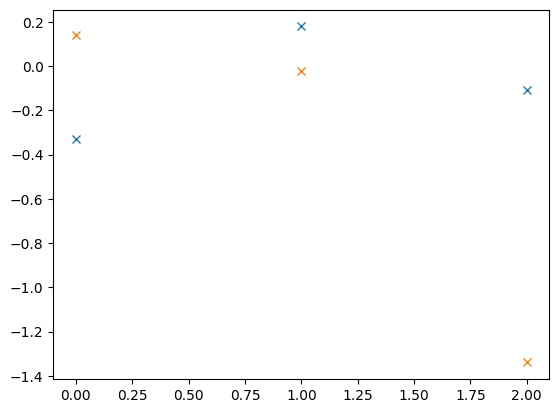

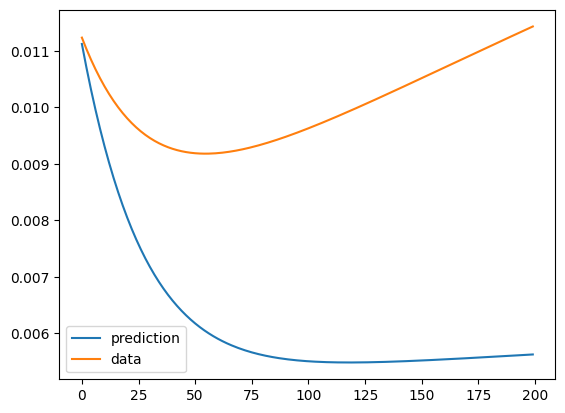

torch.Size([1, 3])
loss =  0.8971120923375242


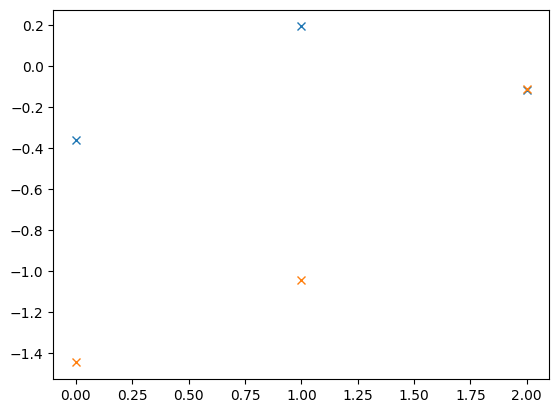

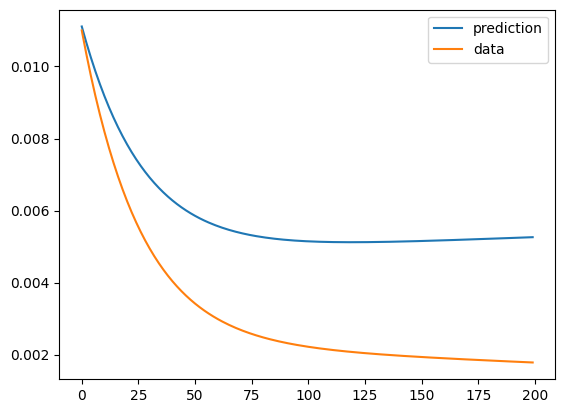

torch.Size([1, 3])
loss =  0.5514099552948273


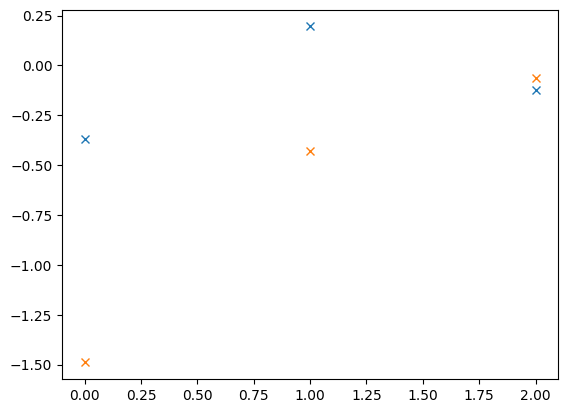

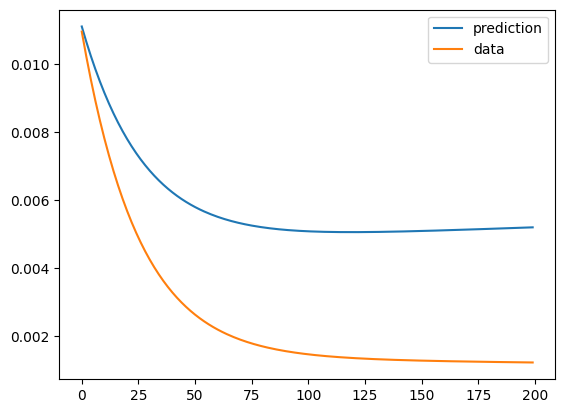

torch.Size([1, 3])
loss =  0.11422773296223411


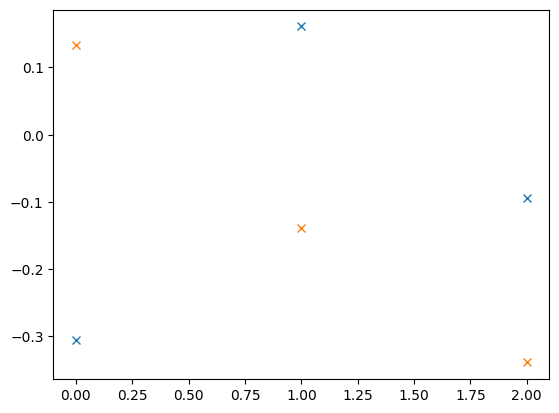

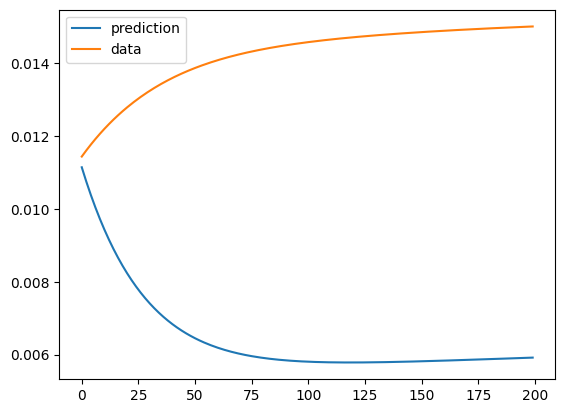

torch.Size([1, 3])
loss =  0.9714020333364551


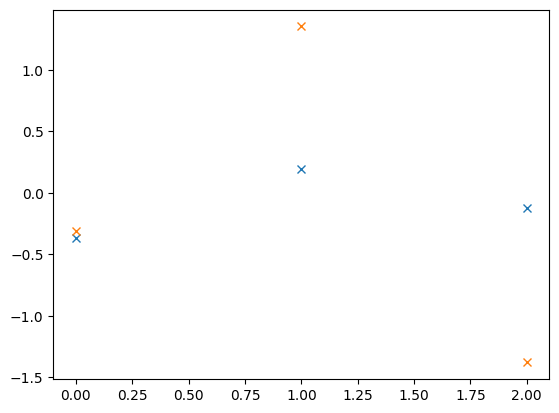

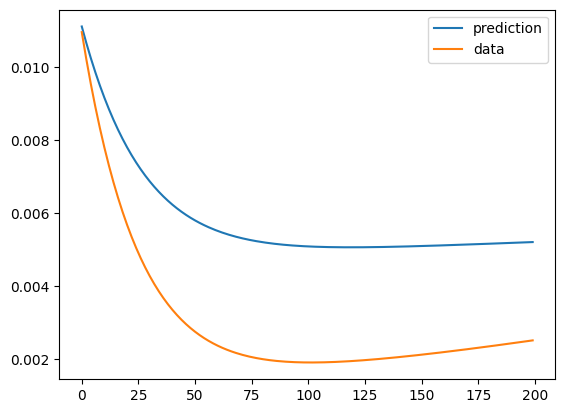

torch.Size([1, 3])
loss =  1.033842075795967


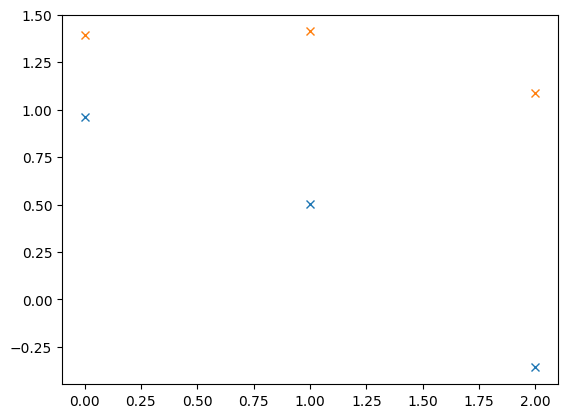

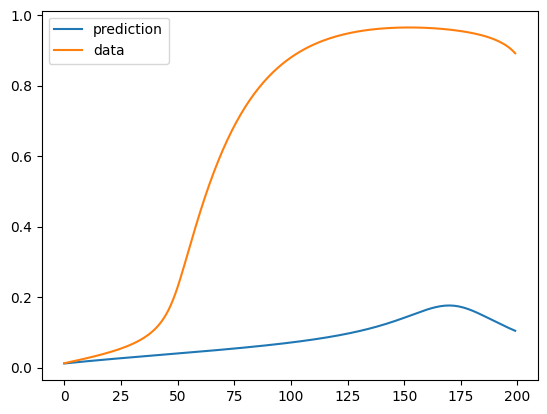

torch.Size([1, 3])
loss =  0.8797079702605292


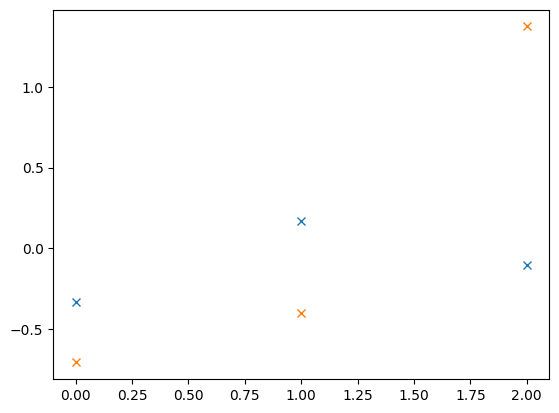

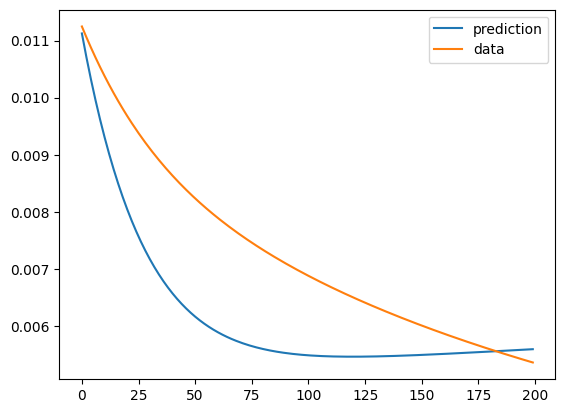

torch.Size([1, 3])
loss =  0.3965079055539961


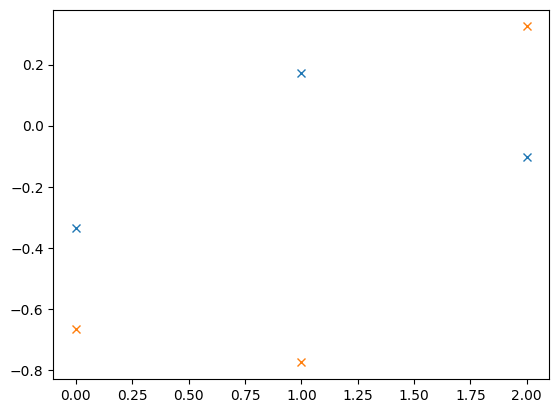

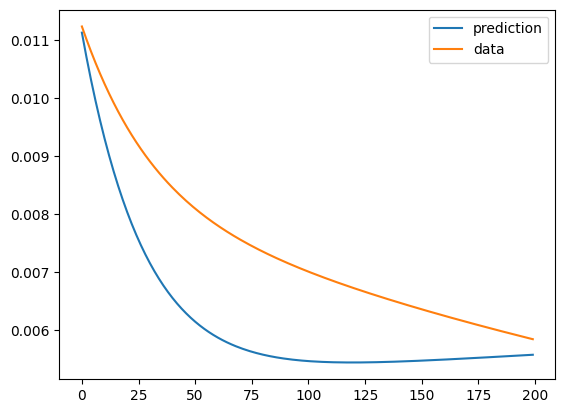

In [531]:
with torch.no_grad():
    for X, y in test_dataloader:
        outputs = model(X)  # Get model outputs
        
        print(outputs.shape)
        print("loss = ", loss_fn(outputs, y).item())

        plt.plot(outputs[0,:], linestyle="none", marker="x")
        plt.plot(y[0,:], linestyle="none", marker="x")
        plt.show()

        inp = polynomial(time, outputs[0,:])
        wc.params["exc_ext"] = inp
        wc.run()
        plt.plot(wc.exc[0,:], label="prediction")

        inp = polynomial(time, y[0,:])
        wc.params["exc_ext"] = inp
        wc.run()
        plt.plot(wc.exc[0,:], label="data")

        plt.legend()
        plt.show()

In [535]:
class DQNetworkModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.dqn = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim),
        )
        self.double()

    def forward(self, x):
        return self.dqn(x)
    
dqn_model = DQNetworkModel(input_dim, output_dim)
print(dqn_model)

DQNetworkModel(
  (dqn): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=200, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=3, bias=True)
  )
)


0
100
200
300
400
500
600
700
800
900
Training Complete


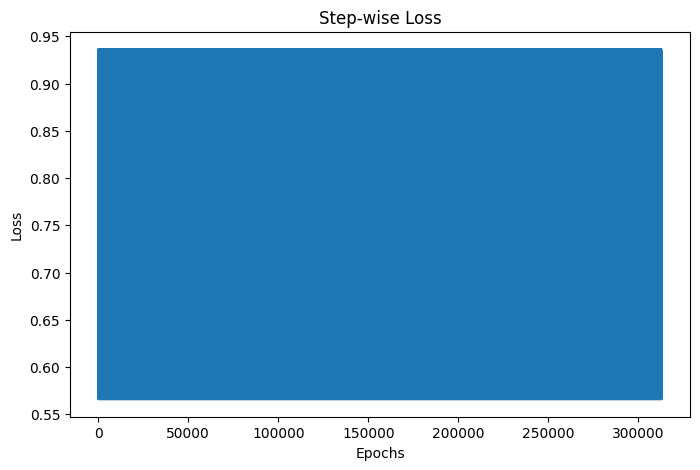

In [536]:
learning_rate = 0.1
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
num_epochs = int(1e3)
loss_values = []

for epoch in range(num_epochs):
    if epoch%100 == 0: print(epoch)
    for X, y in train_dataloader:
        
        # zero the parameter gradients
        optimizer.zero_grad()
       
        # X = output, y = control
        pred = dqn_model(X)
        if False:
            plt.plot(X[0,:].detach().numpy())
            plt.plot(pred[0,:].detach().numpy())
            plt.plot(y[0,:].detach().numpy() )
            plt.show()
        loss = loss_fn(pred, y)
        loss_values.append(loss.item())
        loss.backward()
        optimizer.step()

print("Training Complete")
step = range(len(loss_values))

fig, ax = plt.subplots(figsize=(8,5))
plt.plot(step, np.array(loss_values))
plt.title("Step-wise Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

torch.Size([1, 3])
loss =  0.6062681001869071


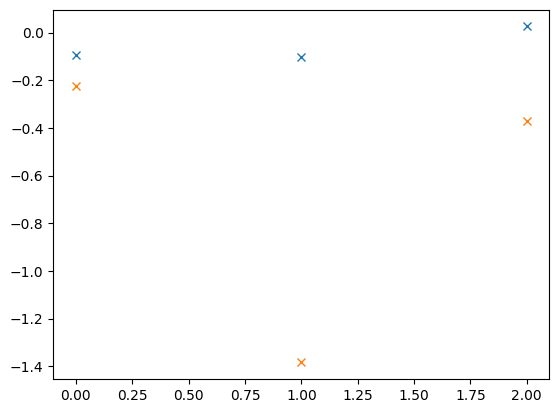

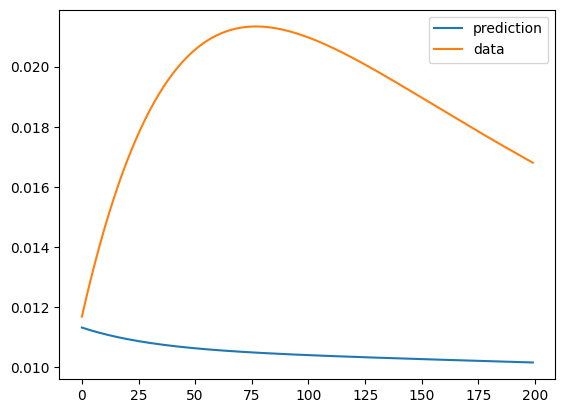

torch.Size([1, 3])
loss =  0.6088076033525573


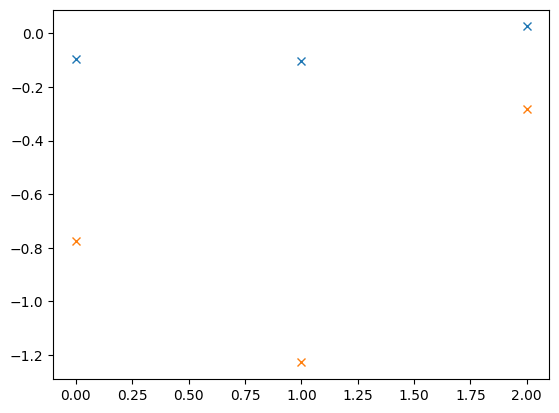

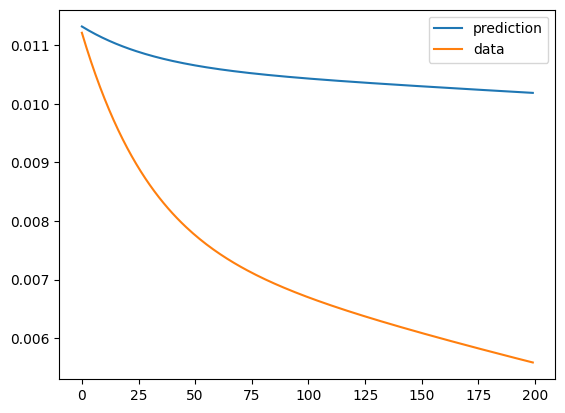

torch.Size([1, 3])
loss =  0.6423676837064932


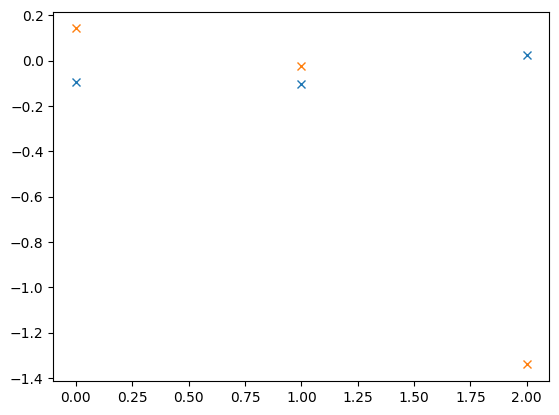

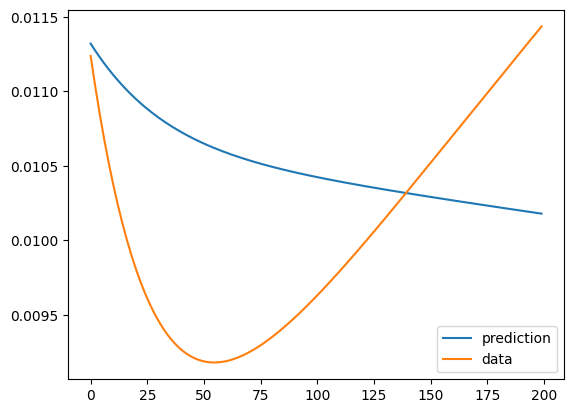

torch.Size([1, 3])
loss =  0.9090362522951526


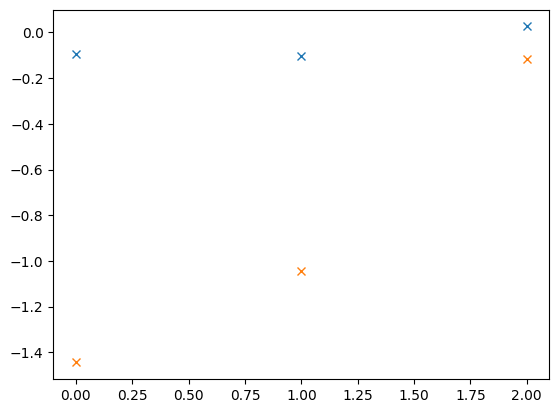

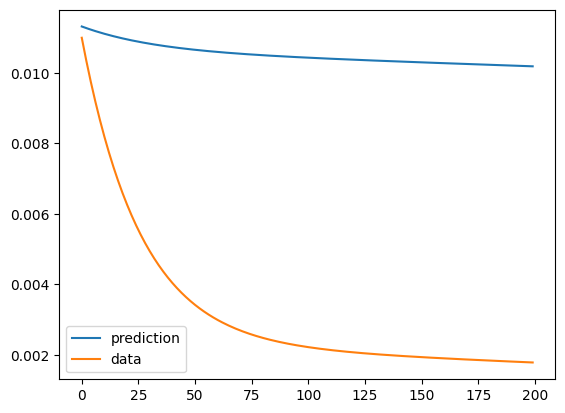

torch.Size([1, 3])
loss =  0.6876791543973922


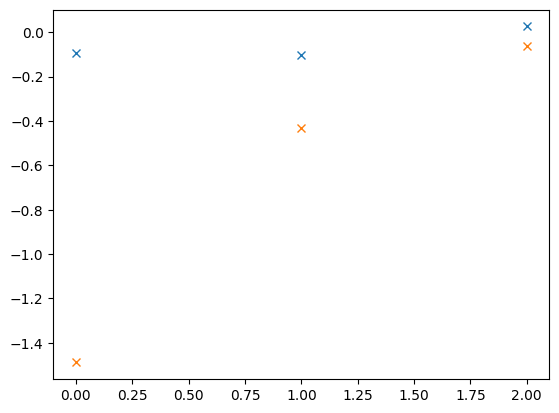

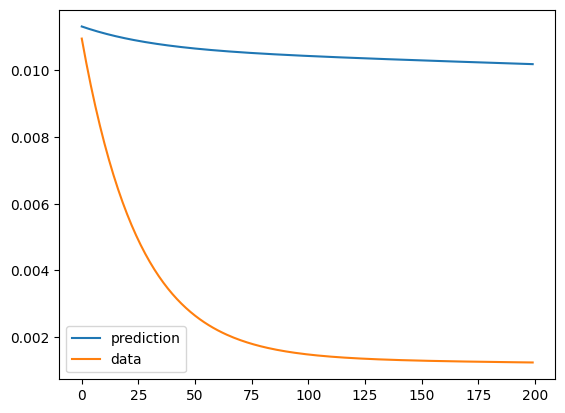

torch.Size([1, 3])
loss =  0.06223701584158406


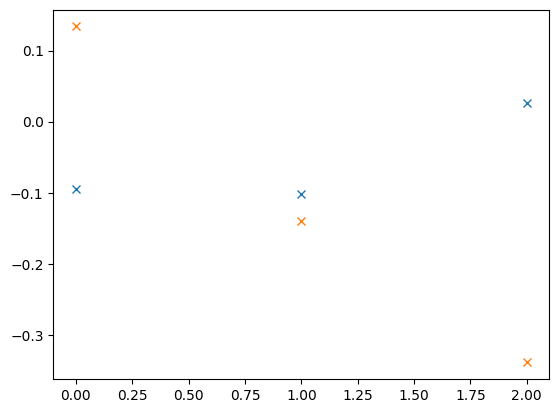

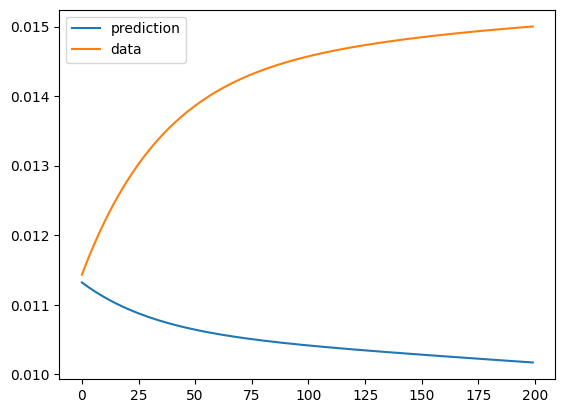

torch.Size([1, 3])
loss =  1.3788789763827107


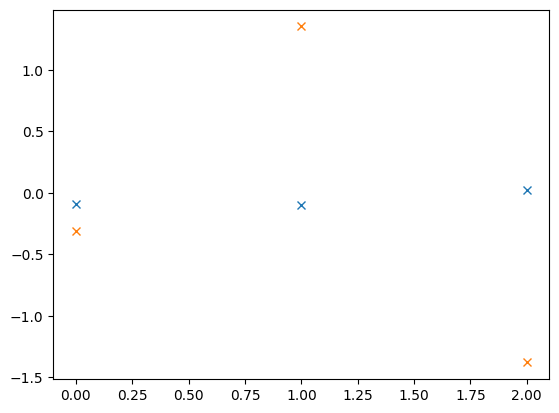

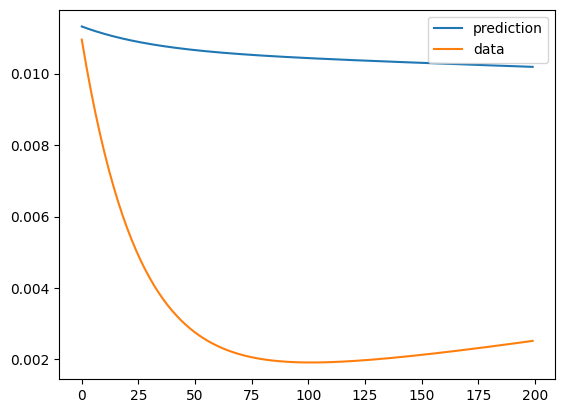

torch.Size([1, 3])
loss =  2.0330433826933505


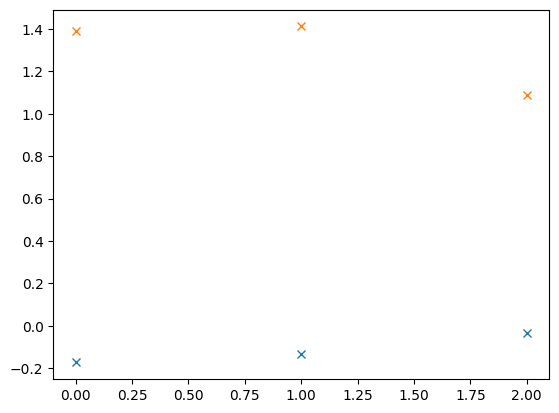

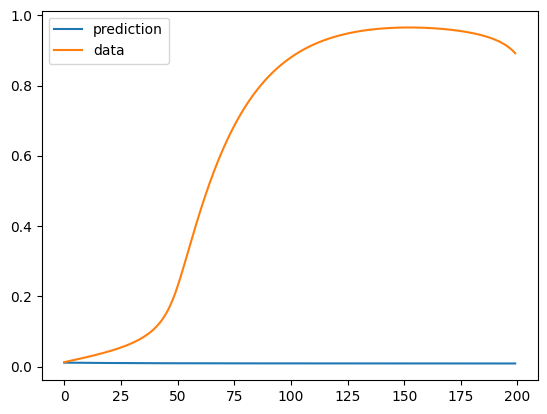

torch.Size([1, 3])
loss =  0.7598316545230063


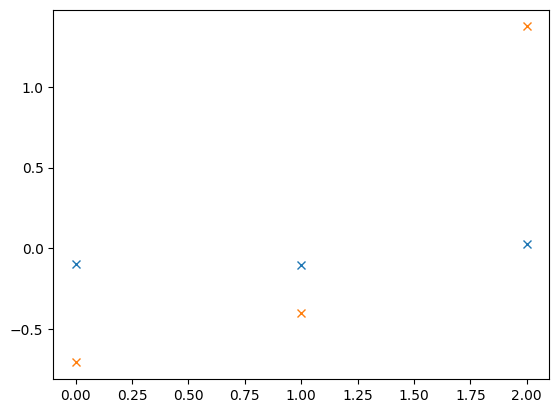

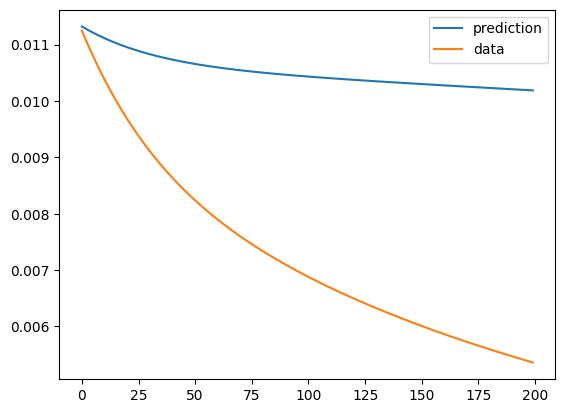

torch.Size([1, 3])
loss =  0.289274553374225


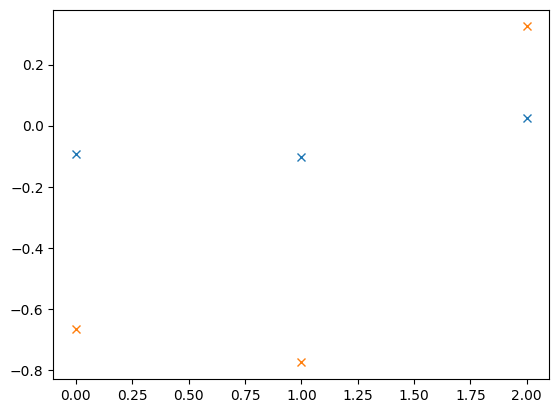

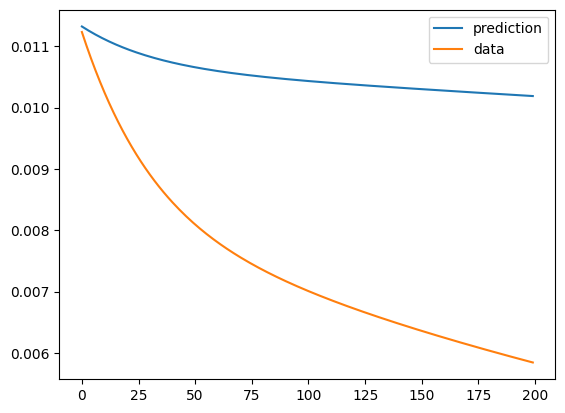

In [537]:
with torch.no_grad():
    for X, y in test_dataloader:
        outputs = dqn_model(X)  # Get model outputs
        
        print(outputs.shape)
        print("loss = ", loss_fn(outputs, y).item())

        plt.plot(outputs[0,:], linestyle="none", marker="x")
        plt.plot(y[0,:], linestyle="none", marker="x")
        plt.show()

        inp = polynomial(time, outputs[0,:])
        wc.params["exc_ext"] = inp
        wc.run()
        plt.plot(wc.exc[0,:], label="prediction")

        inp = polynomial(time, y[0,:])
        wc.params["exc_ext"] = inp
        wc.run()
        plt.plot(wc.exc[0,:], label="data")

        plt.legend()
        plt.show()

In [12]:
def get_state(control):
    wc.params.exc_ext[0] = control
    wc.run()

    return wc.exc[0,:]

In [ ]:
class TimeSeriesControlEnv(gym.Env):
    def __init__(self, time_series, target, max_step=1e5):

        super(TimeSeriesControlEnv, self).__init__()
        
        self.time_series = time_series
        self.target = target
        
        self.current_step = None
        self.state = None
        self.control = np.zeros((target.shape[0]+1))
        
        # Define action space: control input (u_t)
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(target.shape[0]+1,), dtype=np.float32)
        
        # Define observation space: sliding window of time-series values
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(time_series.shape[0],), dtype=np.float32
        )
        self.max_step = max_step

    def reset(self):
        self.current_step = 0
        self.state = self.time_series  # Initialize with the first window
        return self.state

    def step(self, action):
        # Clip the action to ensure it is within bounds
        action = np.clip(action, self.action_space.low, self.action_space.high)
        
        # Apply the action to modify the system dynamics
        new_control = self.control + action
        self.state = get_state(new_control)
        
        # Compute the reward
        reward = - (np.sum((self.state - self.target) ** 2) )#+ 0.1 * np.sum(new_control[0] ** 2))
        #print("reward = ", reward)
        
        # Update the step and check if done
        self.current_step += 1
        done = self.current_step >= self.max_step
        
        return self.state, reward, done, {}

    def render(self, mode="human"):
        print(f"Step: {self.current_step}")

    def close(self):
        pass

In [22]:
env = TimeSeriesControlEnv(time_series=state_timeseries, target=target_timeseries)
model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=int(1e5))

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
-----------------------------
| time/              |      |
|    fps             | 856  |
|    iterations      | 1    |
|    time_elapsed    | 2    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 590         |
|    iterations           | 2           |
|    time_elapsed         | 6           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.075936526 |
|    clip_fraction        | 0.459       |
|    clip_range           | 0.2         |
|    entropy_loss         | -853        |
|    explained_variance   | -0.00046    |
|    learning_rate        | 0.0003      |
|    loss                 | 0.246       |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0508     |
|    std                

Step: 1
Step: 2
Step: 3
Step: 4
Step: 5
Step: 6
Step: 7
Step: 8
Step: 9
Step: 10
Step: 11
Step: 12
Step: 13
Step: 14
Step: 15
Step: 16
Step: 17
Step: 18
Step: 19
Step: 20
Step: 21
Step: 22
Step: 23
Step: 24
Step: 25
Step: 26
Step: 27
Step: 28
Step: 29
Step: 30
Step: 31
Step: 32
Step: 33
Step: 34
Step: 35
Step: 36
Step: 37
Step: 38
Step: 39
Step: 40
Step: 41
Step: 42
Step: 43
Step: 44
Step: 45
Step: 46
Step: 47
Step: 48
Step: 49
Step: 50
Step: 51
Step: 52
Step: 53
Step: 54
Step: 55
Step: 56
Step: 57
Step: 58
Step: 59
Step: 60
Step: 61
Step: 62
Step: 63
Step: 64
Step: 65
Step: 66
Step: 67
Step: 68
Step: 69
Step: 70
Step: 71
Step: 72
Step: 73
Step: 74
Step: 75
Step: 76
Step: 77
Step: 78
Step: 79
Step: 80
Step: 81
Step: 82
Step: 83
Step: 84
Step: 85
Step: 86
Step: 87
Step: 88
Step: 89
Step: 90
Step: 91
Step: 92
Step: 93
Step: 94
Step: 95
Step: 96
Step: 97
Step: 98
Step: 99
Step: 100
Step: 101
Step: 102
Step: 103
Step: 104
Step: 105
Step: 106
Step: 107
Step: 108
Step: 109
Step: 110
Step: 11

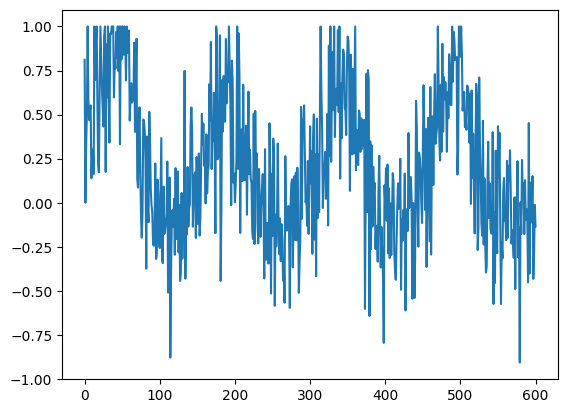

In [23]:
state = env.reset()
done = False

while not done:
    # Use the trained policy to predict the next action
    action, _ = model.predict(state, deterministic=True)
    state, reward, done, _ = env.step(action)
    env.render()

plt.plot(action)

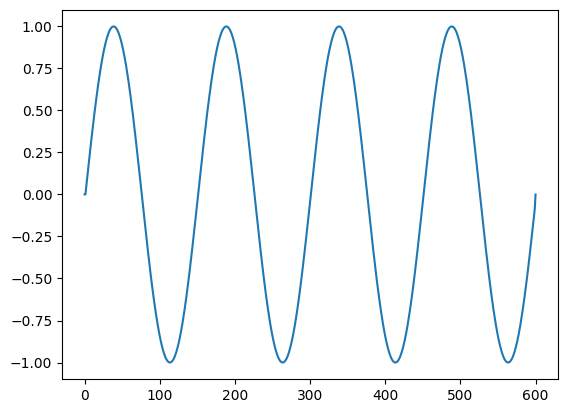

In [16]:
#plt.plot(action)
plt.plot(test_input[0,:])
plt.show()